In [1]:
import os
import pandas as pd

In [2]:
ablation_type = "batch_size"
file_dir = f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_{ablation_type}"
files = os.listdir(file_dir)

In [3]:
len(files)

1367

In [58]:
dfs = []
for f in files:
    df_tmp = pd.read_csv(os.path.join(file_dir, f), index_col=0).T
    df_tmp["num_cytokine_in_train"] = f.split("_")[-2]
    dfs.append(df_tmp)

In [59]:
df = pd.concat(dfs)

In [60]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_MAIT,deg_decoded_r_squared_Treg,deg_decoded_r_squared_NKT,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value,num_cytokine_in_train
Donor1_IL-1Ra,0.8826409777005514,30.793212457176683,0.6615388909975688,0.9173617362976074,0.9451256394386292,0.9294232130050659,0.973563015460968,0.9720611572265625,0.9595789313316345,0.9619995355606079,...,0.07571512460708618,0.7361232042312622,0.7536956071853638,-0.5204044580459595,0.9770914912223816,3.049539109992452,eager-brook-4,2,256,2
Donor1_IL-1Ra,0.8738292455673218,41.1894094870742,0.6106180429458619,0.9077315926551819,0.9399040937423706,0.9302712678909302,0.9656596183776855,0.9513059854507446,0.9568227529525757,0.9510710835456848,...,-0.026451468467712402,0.6712701320648193,0.7205400466918945,-0.5199689865112305,0.9593943357467651,14.693258744363447,crisp-haze-34,3,16,3
Donor1_M-CSF,0.852631680170695,63.82888798426384,0.5451296925544739,0.890640139579773,0.8971158266067505,0.9378052949905396,0.9182084798812866,0.9262816309928894,0.947533130645752,0.9067912697792053,...,0.5189089775085449,0.3959631323814392,0.5154277086257935,-0.14793658256530762,0.935761570930481,33.21497125761948,easy-armadillo-31,17,2048,17
Donor1_OX40L,0.9009098450342814,34.33451528960834,0.769391667842865,0.927749514579773,0.9531307816505432,0.9598214030265808,0.9724794030189514,0.9679232835769653,0.9651998281478882,0.9620852470397949,...,0.2468048334121704,0.875898003578186,0.7716414928436279,0.3555273413658142,0.9765694737434387,7.756738805453097,apricot-sky-73,5,2048,5
Donor1_BAFF,0.8912138064702352,40.01721756985456,0.6199732740720113,0.9120936393737793,0.9415793418884277,0.9583348035812378,0.9771557450294495,0.9643913507461548,0.9636105895042419,0.9603424668312073,...,-0.39454758167266846,0.6272444128990173,0.8207265138626099,-0.638780951499939,0.973881721496582,8.06017781004266,eager-brook-4,2,256,2


In [61]:
ct = pd.crosstab(df["ablation_value"], df["num_cytokine_in_train"])
ct

num_cytokine_in_train,17,2,3,33,5,65,81,9
ablation_value,,,,,,,,
1024,20,0,20,0,20,10,30,20
128,20,20,20,20,20,20,20,10
16,20,10,10,30,30,20,30,30
2048,20,20,10,20,30,10,20,20
256,20,30,20,10,20,30,10,10
32,20,10,20,27,30,20,20,20
4096,20,20,20,20,20,20,0,20
512,20,20,20,10,10,10,20,20
64,20,20,20,20,30,30,30,10


In [62]:
ct.sum(axis=1)

ablation_value
1024    120
128     150
16      180
2048    150
256     150
32      167
4096    140
512     130
64      180
dtype: int64

In [20]:
df.shape

(1367, 53)

In [33]:
df["mean_decoded_r_sq_per_cell_type"] = df["mean_decoded_r_sq_per_cell_type"].astype("float")
df["ood_e_distance"] = df["ood_e_distance"].astype("float")

In [38]:
df_grouped = df[["ablation_value", "mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].groupby("ablation_value")[["mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].mean()

In [39]:
df_grouped

,mean_decoded_r_sq_per_cell_type,ood_e_distance
ablation_value,,
1024,0.889712,17.144428
128,0.888981,15.207545
16,0.888169,19.214101
2048,0.888809,18.812715
256,0.888648,16.404280
32,0.886268,18.836249
4096,0.887552,18.740208
512,0.887538,17.924297
64,0.889961,16.064467


In [40]:
import seaborn as sns

<Axes: xlabel='ablation_value', ylabel='ood_e_distance'>

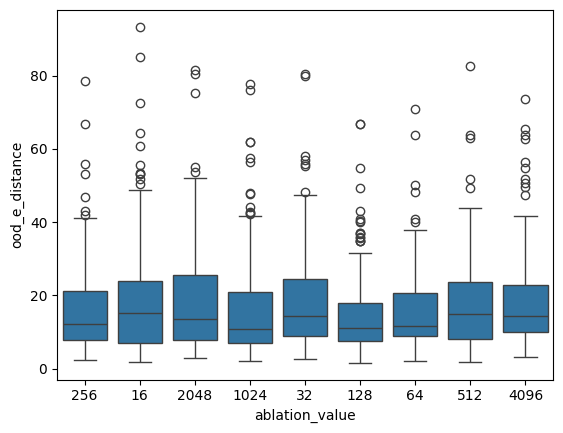

In [41]:
sns.boxplot(df, x="ablation_value", y="ood_e_distance")

<Axes: xlabel='ablation_value', ylabel='mean_decoded_r_sq_per_cell_type'>

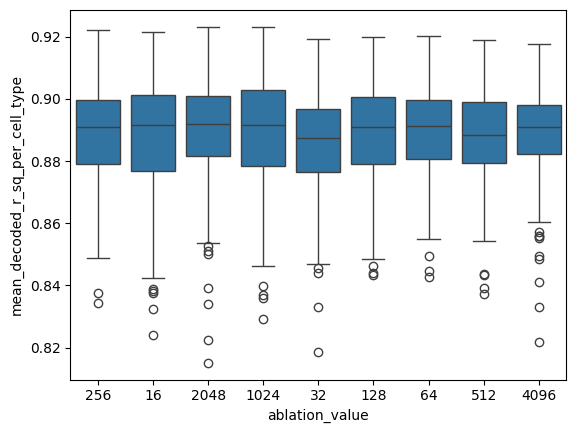

In [42]:
sns.boxplot(df, x="ablation_value", y="mean_decoded_r_sq_per_cell_type")

In [43]:
df.groupby("ablation_value").count()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_CD16 Mono,deg_decoded_r_squared_CD56-bright NK,deg_decoded_r_squared_MAIT,deg_decoded_r_squared_Treg,deg_decoded_r_squared_NKT,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train
ablation_value,,,,,,,,,,,,,,,,,,,,,
1024,120,120,120,120,120,120,120,120,120,120,...,120,120,120,120,108,108,120,120,120,120
128,150,150,150,150,150,150,150,150,150,150,...,150,150,150,150,135,135,150,150,150,150
16,180,180,180,180,180,180,180,180,180,180,...,180,180,180,180,162,162,180,180,180,180
2048,150,150,150,150,150,150,150,150,150,150,...,150,150,150,150,135,135,150,150,150,150
256,150,150,150,150,150,150,150,150,150,150,...,150,150,150,150,135,135,150,150,150,150
32,167,167,167,167,167,167,167,167,167,167,...,167,167,167,167,150,151,167,167,167,167
4096,140,140,140,140,140,140,140,140,140,140,...,140,140,140,140,126,126,140,140,140,140
512,130,130,130,130,130,130,130,130,130,130,...,130,130,130,130,117,117,130,130,130,130
64,180,180,180,180,180,180,180,180,180,180,...,180,180,180,180,162,162,180,180,180,180


In [46]:
df["cytokine_in_train"] = df["cytokine_in_train"].astype("float")
df.groupby("ablation_value")["cytokine_in_train"].mean()

ablation_value
1024    31.333333
128     28.066667
16      30.722222
2048    24.466667
256     24.933333
32      27.311377
4096    19.142857
512     25.153846
64      31.777778
Name: cytokine_in_train, dtype: float64

In [48]:
df.columns

Index(['mean_decoded_r_sq_per_cell_type', 'mean_e_distance_per_cell_type',
       'mean_deg_r_sq_per_cell_type', 'decoded_r_squared_CD8 Naive',
       'decoded_r_squared_B Naive', 'decoded_r_squared_B Intermediate/Memory',
       'decoded_r_squared_CD14 Mono', 'decoded_r_squared_CD4 Naive',
       'decoded_r_squared_CD56-dim NK', 'decoded_r_squared_CD4 Memory',
       'decoded_r_squared_cDC', 'decoded_r_squared_CD8 Memory',
       'decoded_r_squared_CD16 Mono', 'decoded_r_squared_CD56-bright NK',
       'decoded_r_squared_MAIT', 'decoded_r_squared_Treg',
       'decoded_r_squared_NKT', 'decoded_r_squared_pDC',
       'e_distance_CD8 Naive', 'e_distance_B Naive',
       'e_distance_B Intermediate/Memory', 'e_distance_CD14 Mono',
       'e_distance_CD4 Naive', 'e_distance_CD56-dim NK',
       'e_distance_CD4 Memory', 'e_distance_cDC', 'e_distance_CD8 Memory',
       'e_distance_CD16 Mono', 'e_distance_CD56-bright NK', 'e_distance_MAIT',
       'e_distance_Treg', 'e_distance_NKT', 'e_dist

In [49]:
df.shape

(1367, 53)

In [50]:
df

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_CD56-bright NK,deg_decoded_r_squared_MAIT,deg_decoded_r_squared_Treg,deg_decoded_r_squared_NKT,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value
Donor1_IL-1Ra,0.882641,30.793212457176683,0.6615388909975688,0.9173617362976074,0.9451256394386292,0.9294232130050659,0.973563015460968,0.9720611572265625,0.9595789313316345,0.9619995355606079,...,0.5517487525939941,0.07571512460708618,0.7361232042312622,0.7536956071853638,-0.5204044580459595,0.9770914912223816,3.049539,eager-brook-4,2.0,256
Donor1_IL-1Ra,0.873829,41.1894094870742,0.6106180429458619,0.9077315926551819,0.9399040937423706,0.9302712678909302,0.9656596183776855,0.9513059854507446,0.9568227529525757,0.9510710835456848,...,0.45230066776275635,-0.026451468467712402,0.6712701320648193,0.7205400466918945,-0.5199689865112305,0.9593943357467651,14.693259,crisp-haze-34,3.0,16
Donor1_M-CSF,0.852632,63.82888798426384,0.5451296925544739,0.890640139579773,0.8971158266067505,0.9378052949905396,0.9182084798812866,0.9262816309928894,0.947533130645752,0.9067912697792053,...,0.7569611072540283,0.5189089775085449,0.3959631323814392,0.5154277086257935,-0.14793658256530762,0.935761570930481,33.214971,easy-armadillo-31,17.0,2048
Donor1_OX40L,0.900910,34.33451528960834,0.769391667842865,0.927749514579773,0.9531307816505432,0.9598214030265808,0.9724794030189514,0.9679232835769653,0.9651998281478882,0.9620852470397949,...,0.7255970239639282,0.2468048334121704,0.875898003578186,0.7716414928436279,0.3555273413658142,0.9765694737434387,7.756739,apricot-sky-73,5.0,2048
Donor1_BAFF,0.891214,40.01721756985456,0.6199732740720113,0.9120936393737793,0.9415793418884277,0.9583348035812378,0.9771557450294495,0.9643913507461548,0.9636105895042419,0.9603424668312073,...,0.7433806657791138,-0.39454758167266846,0.6272444128990173,0.8207265138626099,-0.638780951499939,0.973881721496582,8.060178,eager-brook-4,2.0,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Donor1_ADSF,0.880497,50.3188859568659,0.5657942136128743,0.9116145968437195,0.9356098175048828,0.9295886754989624,0.9675089716911316,0.9400359392166138,0.9535537362098694,0.9427234530448914,...,0.3129258155822754,-0.16369891166687012,0.7735713124275208,0.7267365455627441,-0.244115948677063,0.9438290596008301,29.301914,azure-river-77,5.0,512
Donor1_IFN-omega,0.866397,76.46293997064355,0.45286104934556143,0.8931915760040283,0.8744574189186096,0.9510257244110107,0.831054151058197,0.9447567462921143,0.9350355267524719,0.9294366240501404,...,0.7268660664558411,0.2757086157798767,0.23850524425506592,NaN,-0.3588395118713379,0.934637188911438,36.114944,honest-aardvark-83,5.0,32
Donor1_FasL,0.912568,27.85119047466787,0.7429607232411702,0.9253429770469666,0.9628574252128601,0.9494667053222656,0.9841914772987366,0.9865337014198303,0.969516396522522,0.9779317378997803,...,0.830254077911377,-0.14691925048828125,0.7907208204269409,0.8741481304168701,0.1506834626197815,0.9724236726760864,12.211833,fiery-disco-87,65.0,256
Donor1_IFN-gamma,0.876669,52.98892152036135,0.5825123310089111,0.9235213994979858,0.9090378880500793,0.9532116651535034,0.8829531669616699,0.9256062507629395,0.9264463186264038,0.9343772530555725,...,0.6935256719589233,0.20242905616760254,0.5870310068130493,0.8141165971755981,-0.0908668041229248,0.9454250335693359,24.721872,valiant-thunder-2,2.0,256


In [51]:
df["cond"] = df.index

In [52]:
df.groupby("ablation_value")["cond"].count()

ablation_value
1024    120
128     150
16      180
2048    150
256     150
32      167
4096    140
512     130
64      180
Name: cond, dtype: int64

In [54]:
pd.crosstab(df["ablation_value"], df["cond"])

cond,Donor1_ADSF,Donor1_BAFF,Donor1_CD27L,Donor1_FasL,Donor1_IFN-gamma,Donor1_IFN-omega,Donor1_IL-1Ra,Donor1_IL-32-beta,Donor1_M-CSF,Donor1_OX40L
ablation_value,,,,,,,,,,
1024,12,12,12,12,12,12,12,12,12,12
128,15,15,15,15,15,15,15,15,15,15
16,18,18,18,18,18,18,18,18,18,18
2048,15,15,15,15,15,15,15,15,15,15
256,15,15,15,15,15,15,15,15,15,15
32,17,17,17,17,17,17,17,16,16,16
4096,14,14,14,14,14,14,14,14,14,14
512,13,13,13,13,13,13,13,13,13,13
64,18,18,18,18,18,18,18,18,18,18
